In [1]:
import os
import sys
from pathlib import Path
import importlib
import torch

In [2]:
#@title Setup
root_path = "/content/drive/MyDrive/MSc/Flood-Mapping"  #@param {type:"string", multiline:true}
Dataset_url = "https://huggingface.co/datasets/tax2310/STURM-fusion-24/resolve/main/Dataset.zip"  #@param {type:"string", multiline:true}
mount_drive = True  #@param {type:"boolean"}
clone_repo = False  #@param {type:"boolean"}

import sys
from pathlib import Path

REPO_URL = "https://github.com/TAX2310/Flood-Mapping.git"

if not mount_drive and not clone_repo:
    raise ValueError("Either mount_drive or clone_repo must be True.")

if mount_drive:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    root_path = "Flood-Mapping"

repo = Path(root_path)

if clone_repo and not repo.exists():
    !git clone $REPO_URL $root_path

assert repo.exists(), f"Repo not found at {repo}. Enable clone_repo or fix root_path."

sys.path.append(str(repo))
from src.config import S1_CFG

cfg = S1_CFG()
cfg.ROOT = repo
cfg.DATASET_URL = Dataset_url
cfg.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Mounted at /content/drive


In [3]:
import src.data.sturm_fusion as SturmFusion

data_root = SturmFusion.download_and_extract(cfg)

img_dir = cfg.S1_PATH
mask_dir = cfg.MASK_PATH

print("Image dir exists:", img_dir.exists())
print("Mask dir exists:", mask_dir.exists())

print("Num images:", len(list(img_dir.glob("*.tif"))))
print("Num masks:", len(list(mask_dir.glob("*.tif"))))

Zip or Dataset already exists, skipping download.
Dataset already extracted, skipping unzip.

Final structure:
 - S1
 - S2
 - floodmaps
 - metadata
Image dir exists: True
Mask dir exists: True
Num images: 1969
Num masks: 1970


In [4]:
requirements = cfg.ROOT / "requirements.txt"
!pip install -r {requirements}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.5 MB/s eta 0:00:00


In [5]:
import src.train.training as training
import src.test.testing as testing
import src.util.io as io
import src.util.plotting as plot

In [ ]:
learning_rates = [1e-3, 1e-4]
batch_sizes = [32, 64]
weight_decays = [0.0, 1e-5]
dropout_rates = [0.0, 0.2]

num_workers = 8

In [ ]:
for learning_rate in learning_rates:
    for batch_size in batch_sizes:
        for weight_decay in weight_decays:
            for dropout_rate in dropout_rates:
                cfg.LR = learning_rate
                cfg.BATCH_SIZE = batch_size
                cfg.WEIGHT_DECAY = weight_decay
                cfg.DROPOUT_RATE = dropout_rate
                training.train_from_file(cfg, num_workers=num_workers)

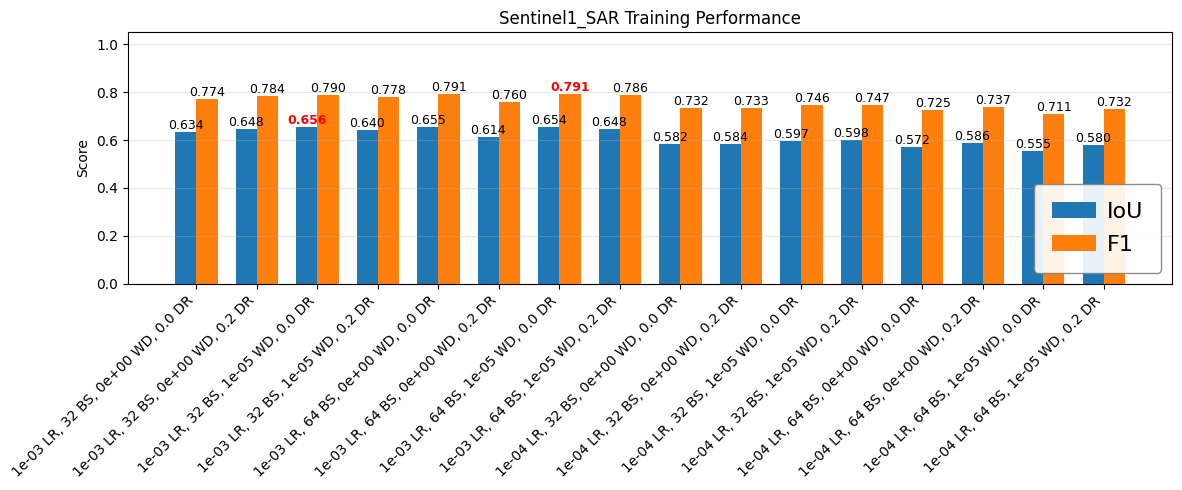

In [11]:
plot.plot_hp_comparison_bar(cfg, save_path=cfg.FIG_EXPORTS_DIR/"s1_hp_iou_f1.pdf")

In [10]:
plot.view_training_metrics(cfg)

Dropdown(description='Model:', layout=Layout(width='700px'), options=(PosixPath('/content/drive/MyDrive/MSc/Fl…

Button(description='Plot metrics', style=ButtonStyle())

Output()

In [ ]:
testing.select_model_to_test(cfg)

In [14]:
import src.inference.inference as inference

samples = ["EMSR470_AOI01_46_07_2_1.tif","EMSR441_AOI05_2_3_2_2.tif","EMSR570_AOI02_07_03_2_1.tif"]

#samples = ["EMSR470_AOI01_29_13_2_2.tif", "EMSR407_AOI01_03_17_2_1.tif", "EMSR470_AOI01_10_25_1_1.tif", "EMSR470_AOI01_47_10_1_2.tif", "EMSR629_AOI01_09_01_1_2.tif"]

results = inference.inference(cfg, cfg.S1_MODEL, samples)
all_results = inference.inference(cfg, cfg.S1_MODEL)
io.create_inference_results_csv(cfg, all_results, cfg.METADATA_CSV, cfg.S1_TEST_RESULTS_CSV)

Model directory: /content/drive/MyDrive/MSc/Flood-Mapping/experiments/STURM-fusion-24/Sentinel1_SAR/lr_0.001/bs_32/wd_1e-05/dr_0.0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


id: torch.Size([1])
sample_id: EMSR407_AOI01_03_17_2_1.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR407_AOI01_03_17_2_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR407_AOI01_03_17_2_1.tif
accuracy: 0.91229248046875
precision: 0.04330708831548691
recall: 0.08644400537014008
f1: 0.057704877108335495
iou: 0.029709655791521072


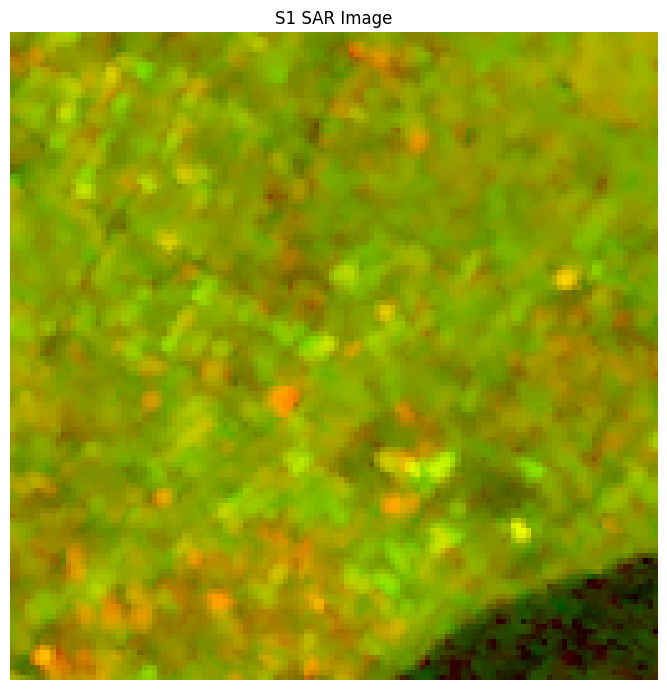

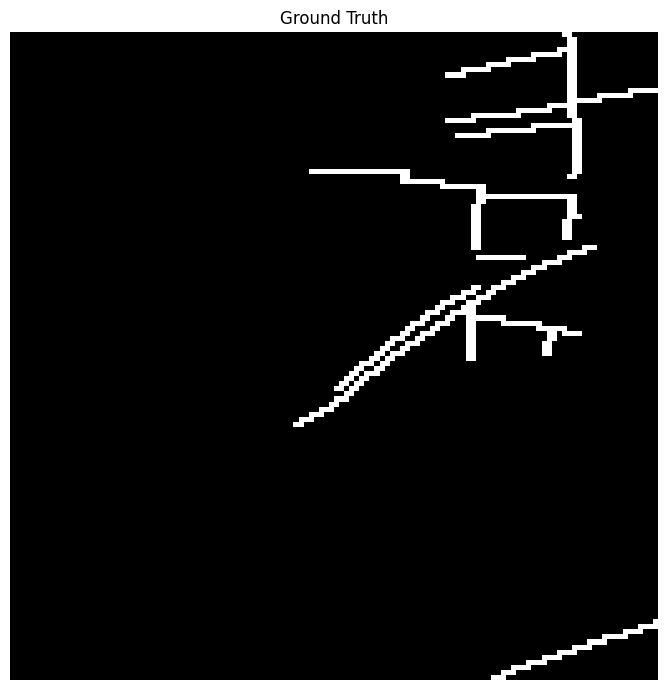

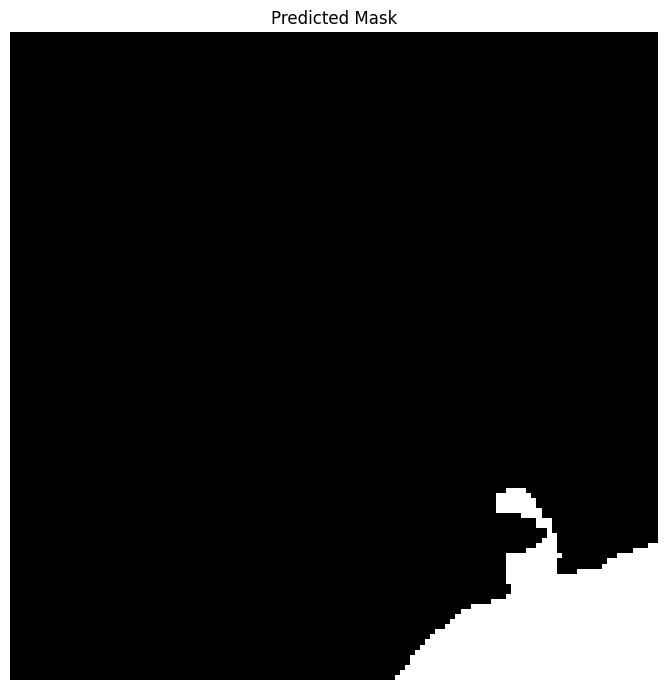

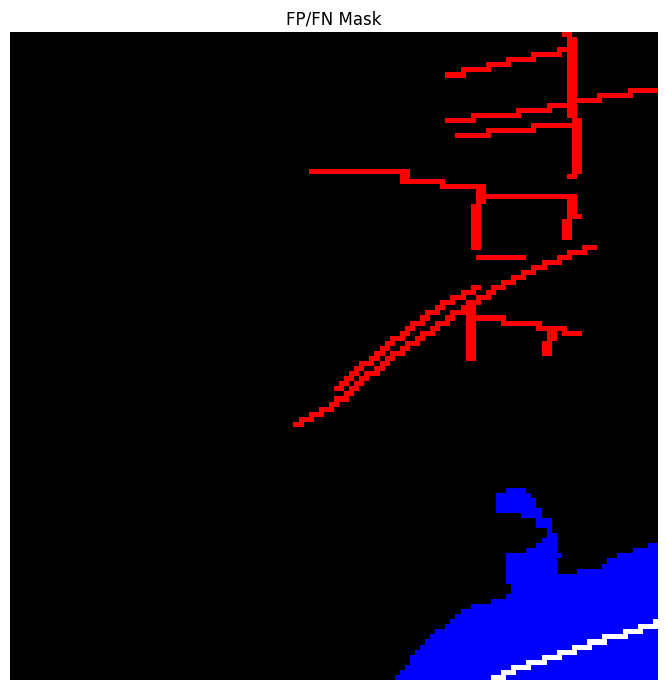

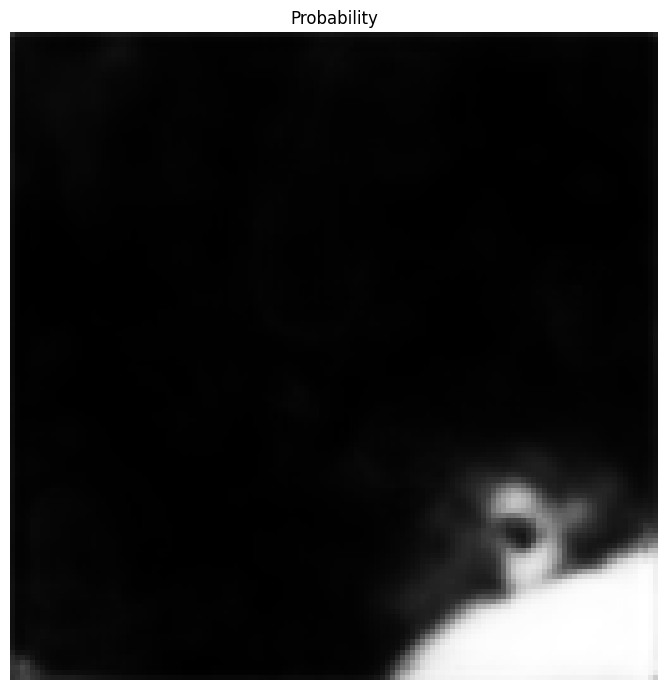

id: torch.Size([1])
sample_id: EMSR470_AOI01_10_25_1_1.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR470_AOI01_10_25_1_1.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_10_25_1_1.tif
accuracy: 0.8857421875
precision: 0.9118082523345947
recall: 0.6618689298629761
f1: 0.7669902443885803
iou: 0.6220472455024719


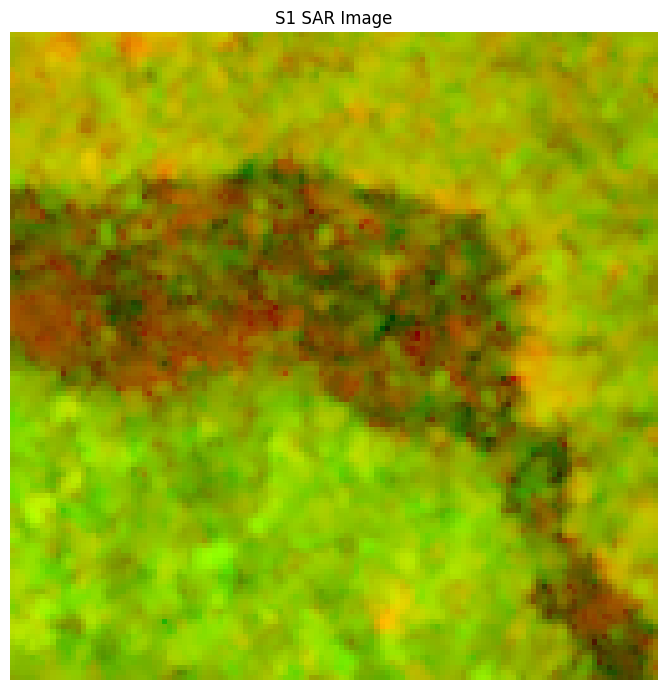

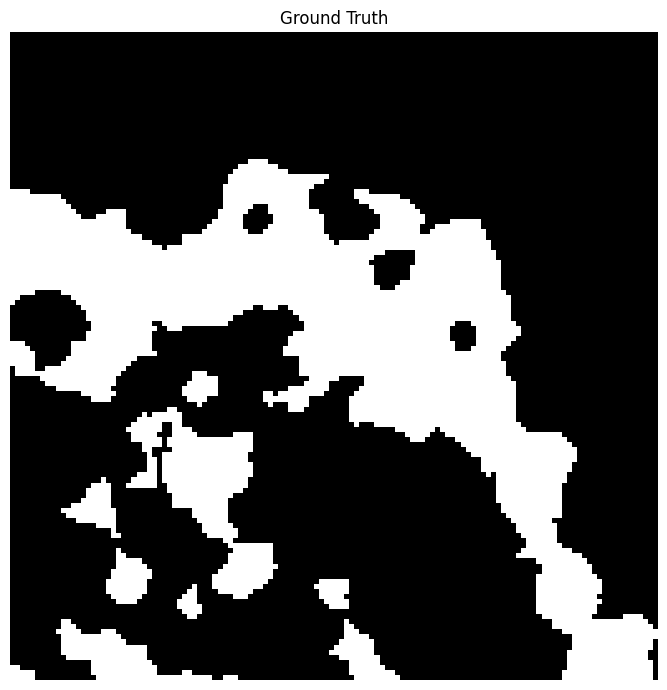

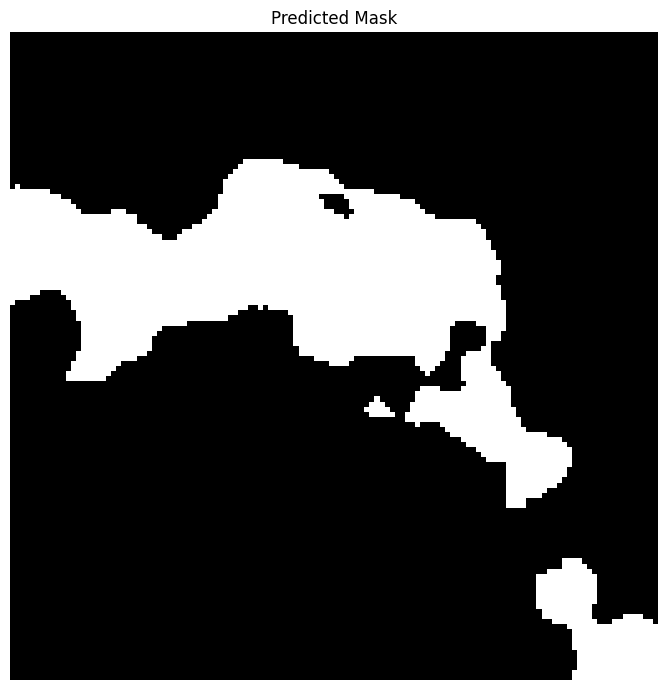

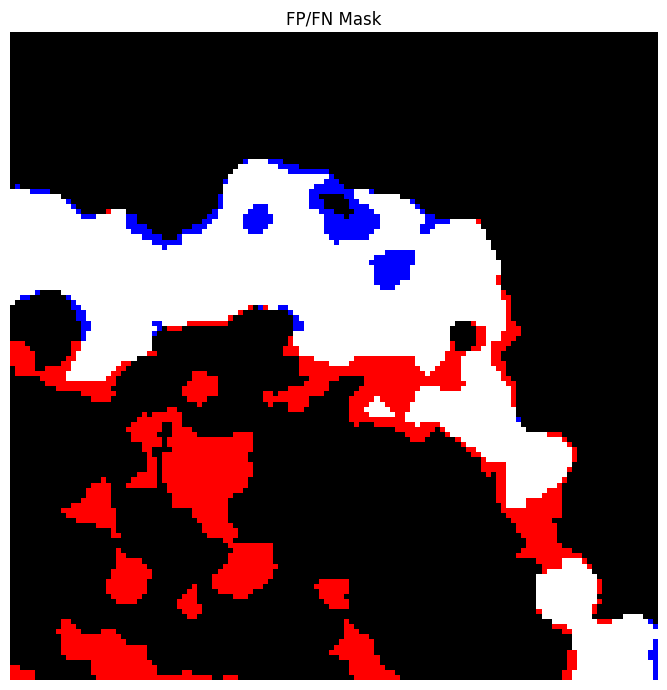

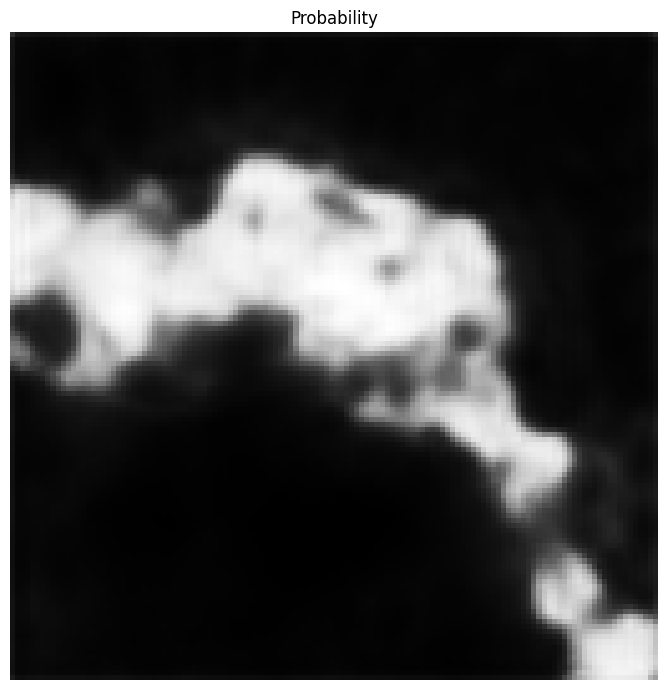

id: torch.Size([1])
sample_id: EMSR470_AOI01_29_13_2_2.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR470_AOI01_29_13_2_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_29_13_2_2.tif
accuracy: 0.9879150390625
precision: 0.9897328615188599
recall: 0.9884233474731445
f1: 0.989077627658844
iou: 0.9783913493156433


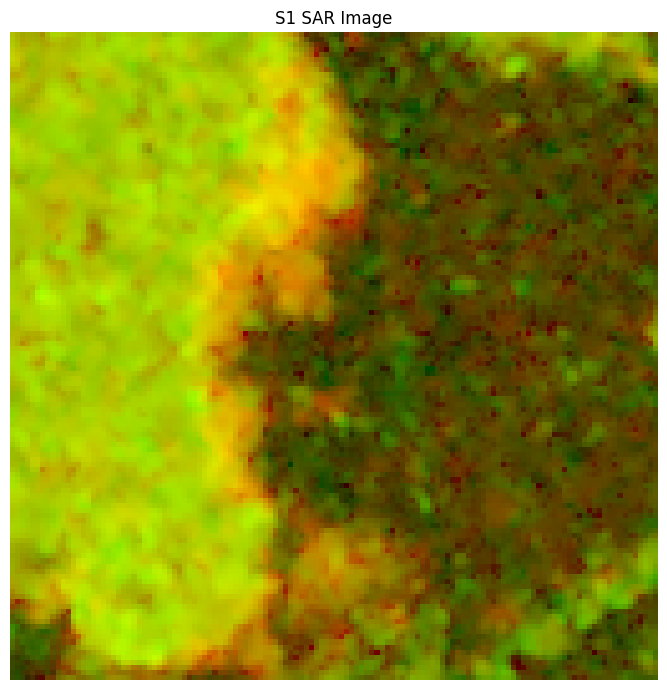

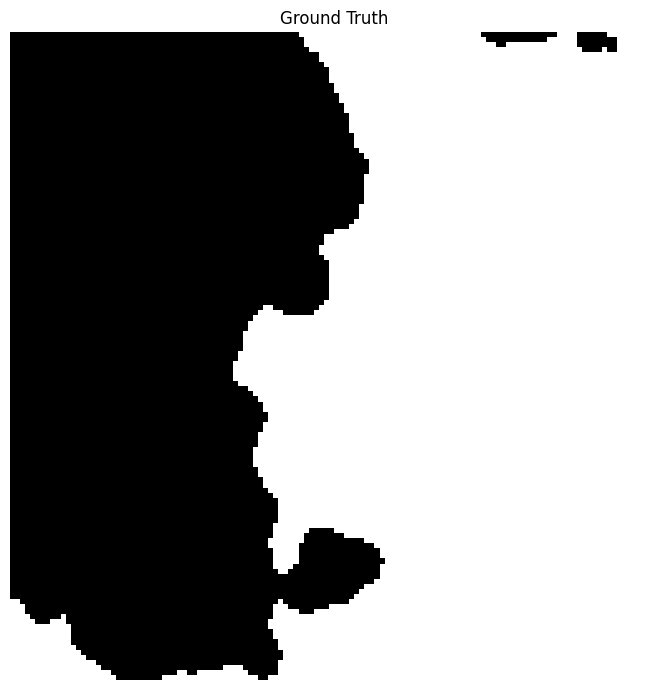

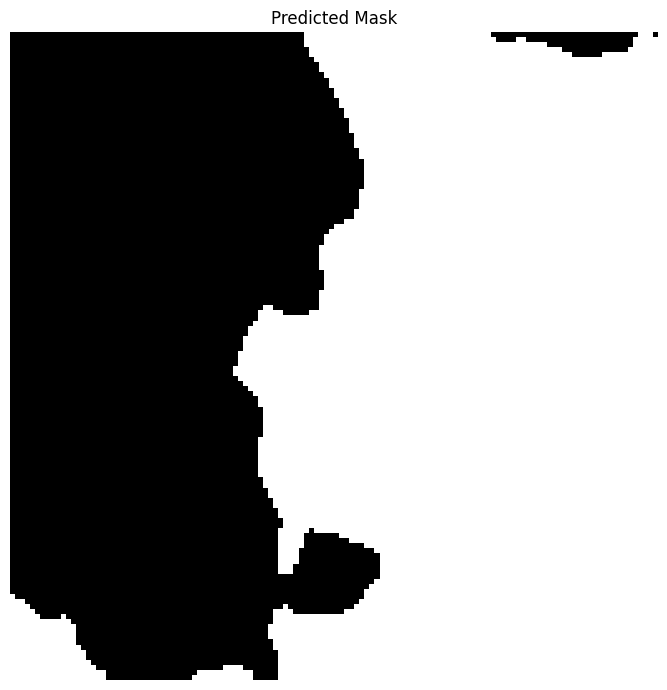

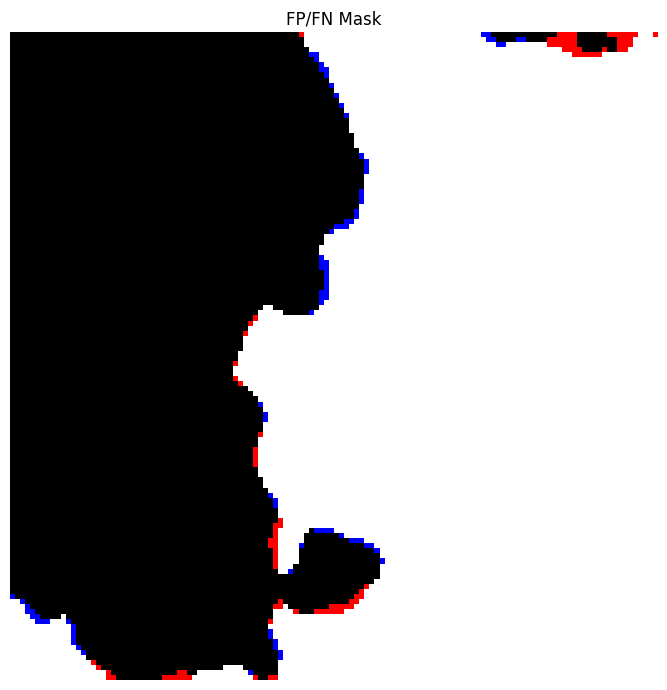

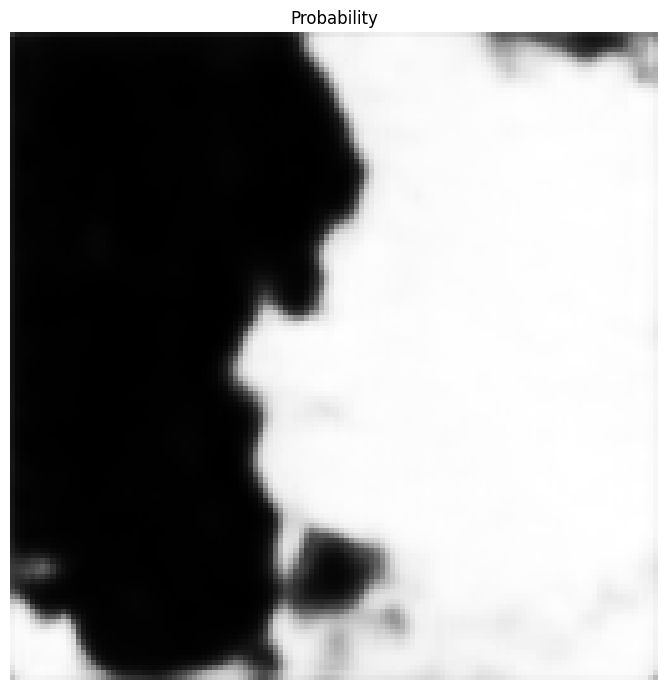

id: torch.Size([1])
sample_id: EMSR470_AOI01_47_10_1_2.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR470_AOI01_47_10_1_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR470_AOI01_47_10_1_2.tif
accuracy: 0.95849609375
precision: 0.8086591958999634
recall: 0.865902304649353
f1: 0.8363022804260254
iou: 0.718659520149231


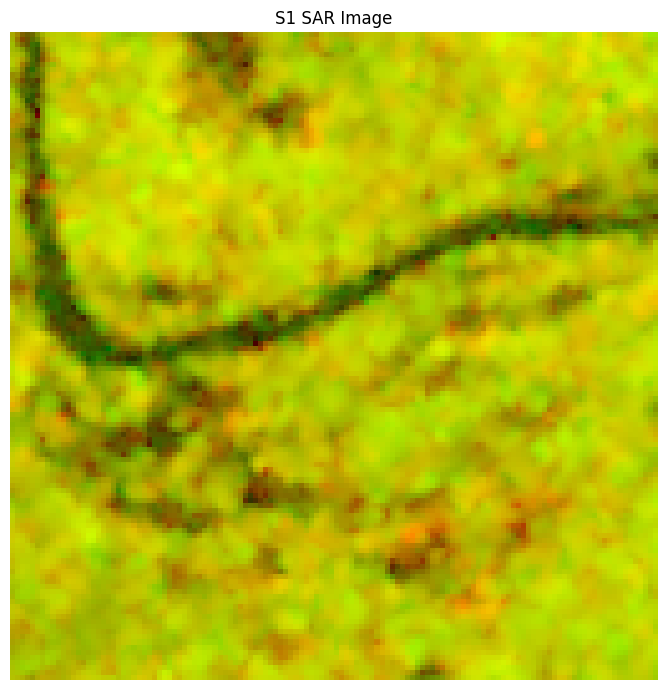

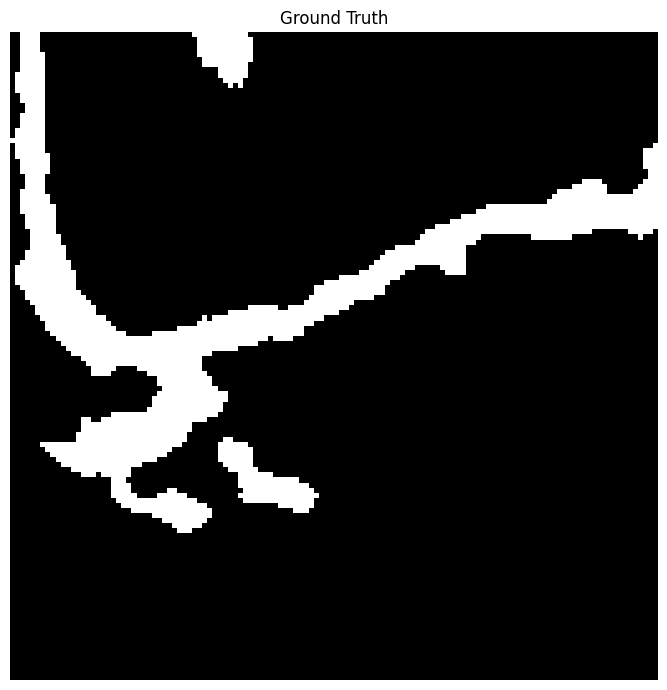

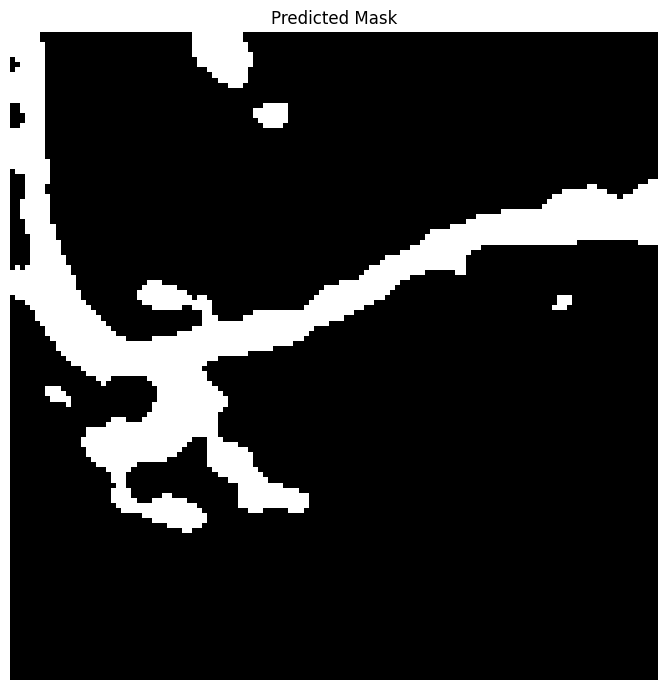

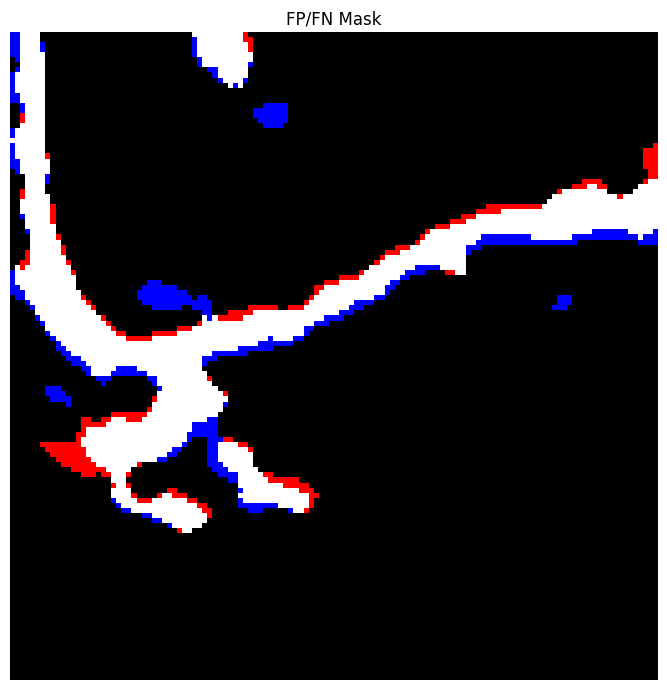

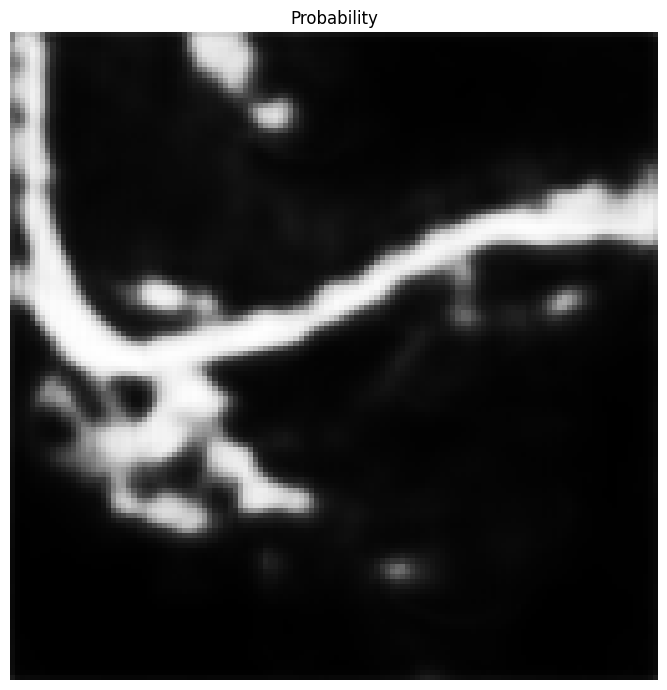

id: torch.Size([1])
sample_id: EMSR629_AOI01_09_01_1_2.tif
image: torch.Size([1, 2, 128, 128])
mask: torch.Size([1, 1, 128, 128])
prob: torch.Size([128, 128])
pred: torch.Size([128, 128])
reference_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/S1/EMSR629_AOI01_09_01_1_2.tif
mask_path: /content/drive/MyDrive/MSc/Flood-Mapping/Dataset/floodmaps/EMSR629_AOI01_09_01_1_2.tif
accuracy: 0.969482421875
precision: 0.9912713766098022
recall: 0.9774229526519775
f1: 0.9842984080314636
iou: 0.9690823554992676


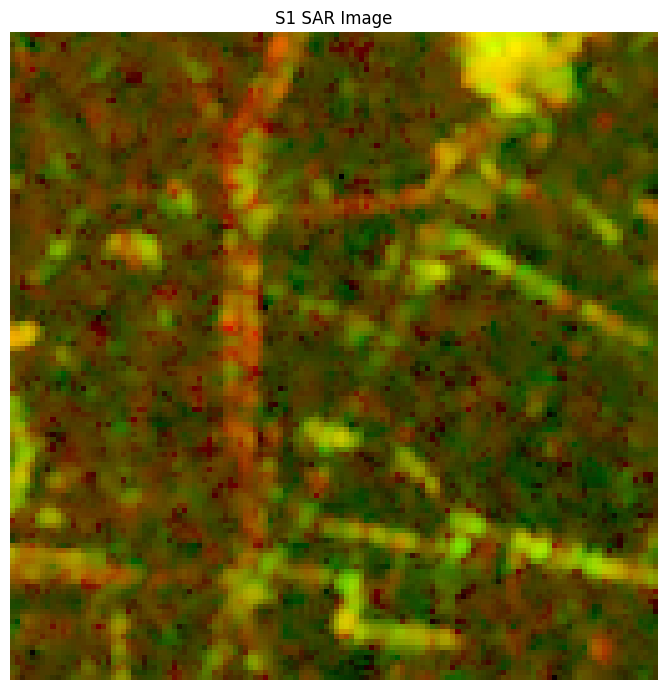

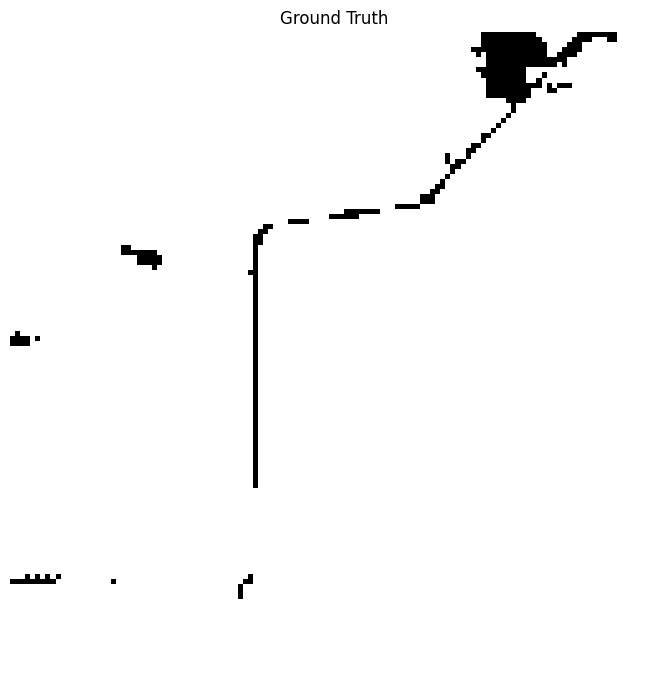

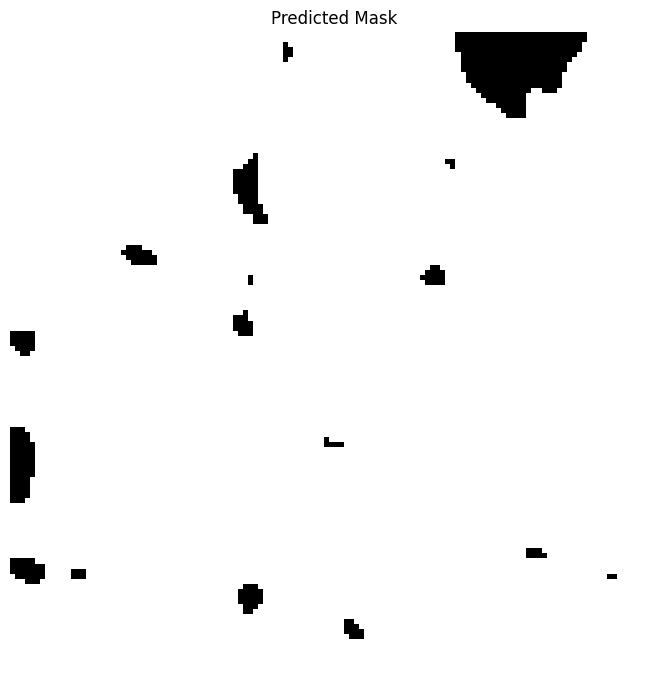

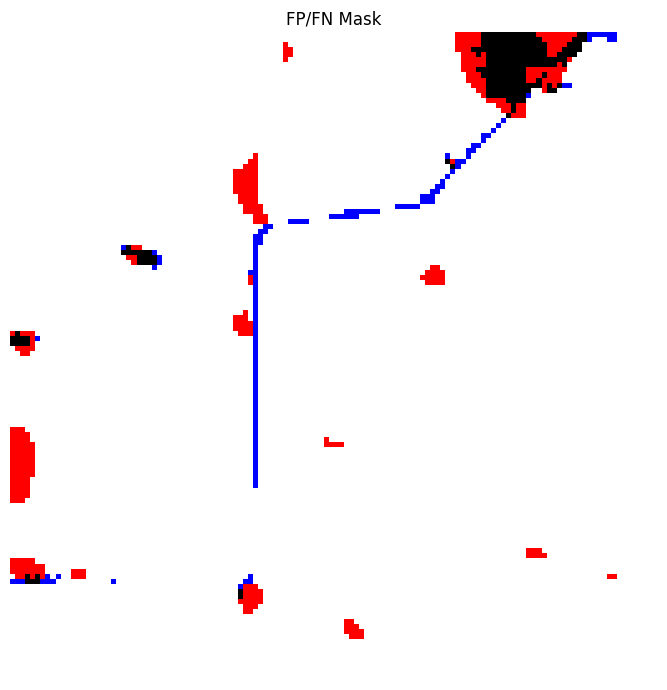

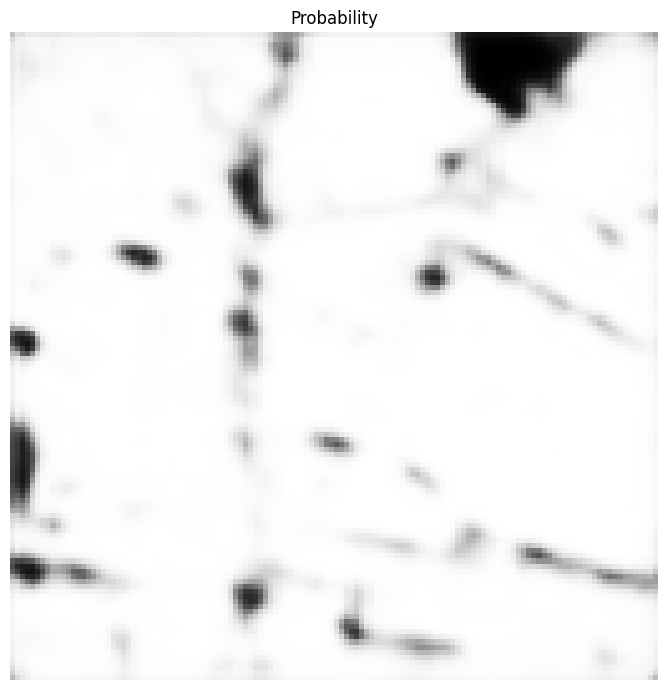

In [16]:
plot.plot_sample_results(cfg, results)

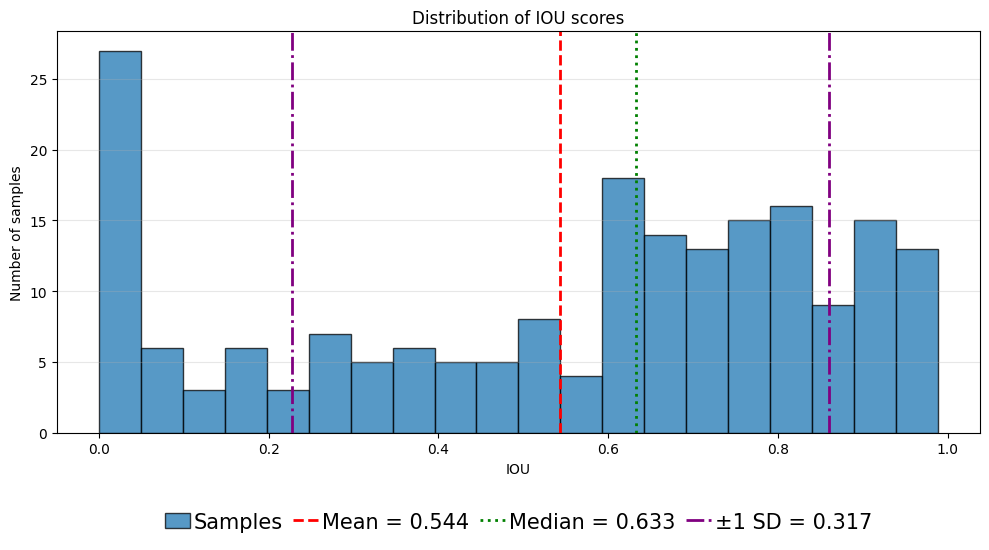

In [6]:
plot.plot_metric_distribution_from_csv(cfg.S1_TEST_RESULTS_CSV, save_path=cfg.FIG_EXPORTS_DIR/"s1_iou_dist.pdf")

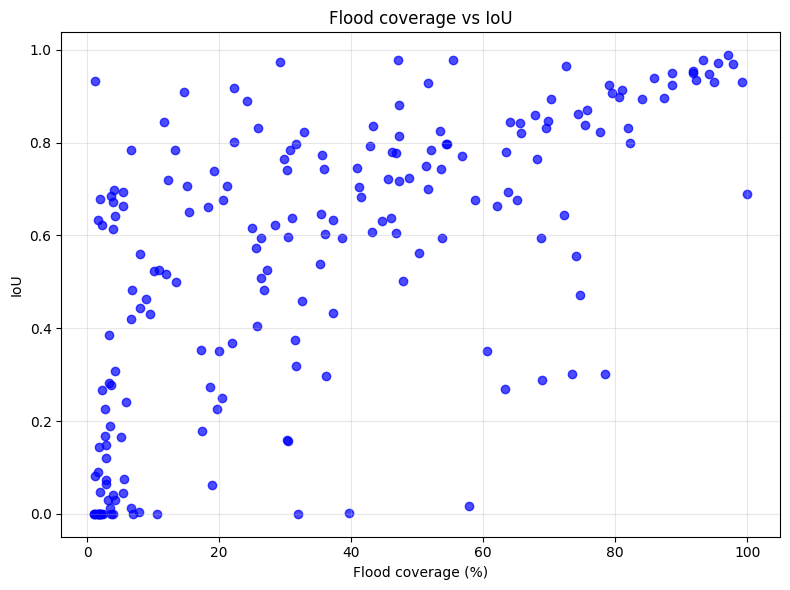

In [7]:
plot.plot_iou_vs_flood_scatter([cfg.S1_TEST_RESULTS_CSV], save_path=cfg.FIG_EXPORTS_DIR/"s1_scatter.pdf", show_legend=False)

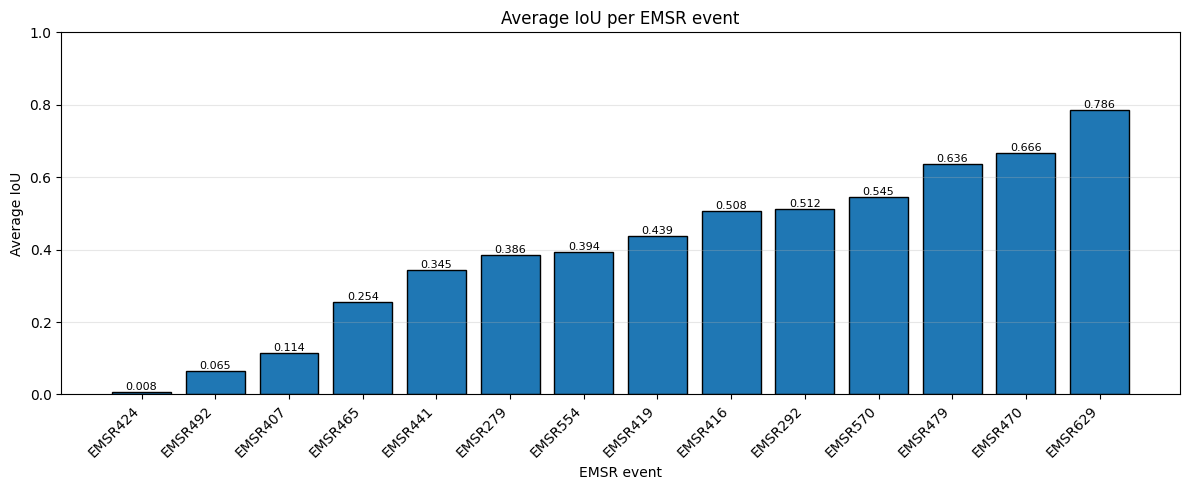

In [12]:
plot.plot_average_iou_per_event(cfg.S1_TEST_RESULTS_CSV, save_path=cfg.FIG_EXPORTS_DIR/"s1_iou_per_event.pdf")